# 单个被试正确率

准备方差分析数据...
读取Excel文件: /Users/zhangqianqian/Desktop/chujue_1204_1_1.xlsx
数据加载完成，共 192 行，11 列
列名: ['Subject', 'Gender', 'Age', 'Version', 'Ntrials', 'Cue', 'Shape', 'Report', 'choice', 'feedback', 'RT']
剔除无效RT前的数据量：192
剔除无效RT后的数据量：192

各条件的试次数量统计:
   图形规则性  报告一致性  试次数
0  不规则图形   一致条件   72
1  不规则图形  不一致条件   24
2   规则图形   一致条件   72
3   规则图形  不一致条件   24

各条件的平均正确率:
   图形规则性  报告一致性       正确率      正确率百分比
0  不规则图形   一致条件  0.958333   95.833333
1  不规则图形  不一致条件  0.958333   95.833333
2   规则图形   一致条件  0.986111   98.611111
3   规则图形  不一致条件  1.000000  100.000000

按被试计算的正确率统计:
   图形规则性  报告一致性       平均正确率  标准差  被试数
0  不规则图形   一致条件   95.833333  NaN    1
1  不规则图形  不一致条件   95.833333  NaN    1
2   规则图形   一致条件   98.611111  NaN    1
3   规则图形  不一致条件  100.000000  NaN    1

开始进行正确率方差分析...

方差分析结果:
                 sum_sq     df         F    PR(>F)
C(规则性)         0.046875    1.0  1.828530  0.177926
C(一致性)         0.001736    1.0  0.067723  0.794966
C(规则性):C(一致性)  0.001736    1.0  0.067723  0.794966
Residual     

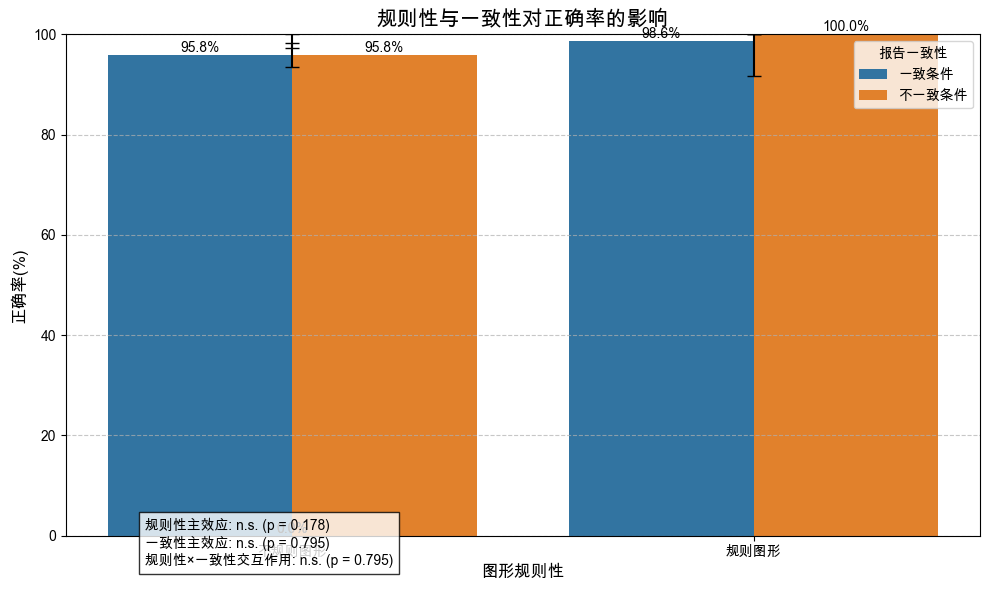

In [3]:
# 准备进行方差分析
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats
import pingouin as pg
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 创建输出文件夹
output_folder = '/Users/zhangqianqian/Desktop/output'
anova_folder = os.path.join(output_folder, '方差分析结果')
os.makedirs(anova_folder, exist_ok=True)

print("准备方差分析数据...")

try:
    # 指定数据文件路径
    data_path = '/Users/zhangqianqian/Desktop/chujue_1204_1_1.xlsx'  # Excel文件
    
    # 使用正确的函数读取Excel数据
    print(f"读取Excel文件: {data_path}")
    df = pd.read_excel(data_path)  # 使用read_excel而非read_csv
    print(f"数据加载完成，共 {df.shape[0]} 行，{df.shape[1]} 列")
    print(f"列名: {df.columns.tolist()}")
    
    # 检查RT列是否存在，剔除无效RT
    if 'RT' in df.columns:
        print(f"剔除无效RT前的数据量：{len(df)}")
        df = df[df['RT'] != -999].copy()
        print(f"剔除无效RT后的数据量：{len(df)}")
    
    # 创建正确的变量
    df['shape_str'] = df['Shape'].astype(str)
    
    # 提取左右手的图形
    df['left_digit'] = df['shape_str'].str[0].astype(int)
    df['right_digit'] = df['shape_str'].str[1].astype(int)
    
    # ===== 正确实现条件一致性和图形规则性的逻辑 =====
    # 一致性逻辑:
    # - 当Cue=0(左手)且Report=0(左手)时，为一致条件，查看的是左侧图形
    # - 当Cue=1(右手)且Report=1(右手)时，为一致条件，查看的是右侧图形
    # - 当Cue=0(左手)且Report=1(右手)时，为不一致条件，查看的是右侧图形
    # - 当Cue=1(右手)且Report=0(左手)时，为不一致条件，查看的是左侧图形
    
    # 首先标记一致性
    df['报告一致性'] = np.where(df['Cue'] == df['Report'], '一致条件', '不一致条件')
    
    # 然后根据报告位置和一致性确定被试看到的图形数字
    # 如果是一致条件: 当Cue=0看左侧，当Cue=1看右侧
    # 如果是不一致条件: 当Cue=0看右侧，当Cue=1看左侧
    df['viewed_digit'] = np.where(
        df['报告一致性'] == '一致条件',
        # 一致条件: Cue=0看左边数字，Cue=1看右边数字
        np.where(df['Cue'] == 0, df['left_digit'], df['right_digit']),
        # 不一致条件: Cue=0看右边数字，Cue=1看左边数字
        np.where(df['Cue'] == 0, df['right_digit'], df['left_digit'])
    )
    
    # 判断规则性：1和2是规则图形，3和4是不规则图形
    df['图形规则性'] = np.where(df['viewed_digit'].isin([1, 2]), '规则图形', '不规则图形')
    
    # 转换feedback为是否正确
    df['是否正确'] = df['feedback'].astype(int)  # 1=正确，0=错误
    
    # 打印分类统计
    print("\n各条件的试次数量统计:")
    condition_counts = df.groupby(['图形规则性', '报告一致性']).size().reset_index(name='试次数')
    print(condition_counts)
    
    # 打印各条件的正确率
    print("\n各条件的平均正确率:")
    condition_acc = df.groupby(['图形规则性', '报告一致性'])['是否正确'].mean().reset_index(name='正确率')
    condition_acc['正确率百分比'] = condition_acc['正确率'] * 100
    print(condition_acc)
    
    # 计算每个被试在每个条件下的正确率
    subject_acc = df.groupby(['Subject', '图形规则性', '报告一致性'])['是否正确'].mean().reset_index()
    subject_acc['正确率'] = subject_acc['是否正确'] * 100  # 转换为百分比
    
    # 打印各条件下的描述性统计
    acc_stats = subject_acc.groupby(['图形规则性', '报告一致性'])['正确率'].agg([
        ('平均正确率', 'mean'),
        ('标准差', 'std'),
        ('被试数', 'count')
    ]).reset_index()
    
    print("\n按被试计算的正确率统计:")
    print(acc_stats)
    
    # 保存条件统计结果
    acc_stats.to_csv(os.path.join(anova_folder, '正确率条件统计.csv'), index=False, encoding='utf-8-sig')
    
    # ===== 进行方差分析 =====
    print("\n开始进行正确率方差分析...")
    
    try:
        # 单被试方差分析 (针对试次水平的数据)
        # 准备方差分析数据
        anova_data = df.copy()
        anova_data['规则性'] = np.where(anova_data['图形规则性'] == '规则图形', 1, 0)  # 1=规则, 0=不规则
        anova_data['一致性'] = np.where(anova_data['报告一致性'] == '一致条件', 1, 0)  # 1=一致, 0=不一致
        
        # 构建方差分析模型 (针对trial level数据)
        formula = '是否正确 ~ C(规则性) * C(一致性)'
        model = ols(formula, data=anova_data).fit()
        aov_table = sm.stats.anova_lm(model, typ=2)
        
        print("\n方差分析结果:")
        print(aov_table)
        
        # 检查是否有显著效应并添加注释
        p_values = {}
        effect_names = {
            'C(规则性)': '规则性主效应',
            'C(一致性)': '一致性主效应',
            'C(规则性):C(一致性)': '规则性×一致性交互作用'
        }
        
        for effect in effect_names.keys():
            if effect in aov_table.index:
                p_value = aov_table.loc[effect, 'PR(>F)']
                p_values[effect] = p_value
                
                # 打印效应是否显著
                sig_level = '*' * sum([p_value < level for level in [0.05, 0.01, 0.001]])
                if sig_level:
                    print(f"{effect_names[effect]}: p = {p_value:.4f} {sig_level}")
                else:
                    print(f"{effect_names[effect]}: p = {p_value:.4f} (不显著)")
        
        # 保存方差分析结果
        aov_table.to_csv(os.path.join(anova_folder, '正确率方差分析结果.csv'), index=True, encoding='utf-8-sig')
        
        # ===== 创建图表 =====
        plt.figure(figsize=(10, 6))
        
        # 计算每种条件的正确率
        condition_stats = df.groupby(['图形规则性', '报告一致性'])['是否正确'].agg(['mean', 'std', 'count']).reset_index()
        condition_stats['mean'] = condition_stats['mean'] * 100  # 转换为百分比
        condition_stats['sem'] = condition_stats['std'] * 100 / np.sqrt(condition_stats['count'])
        
        # 创建条形图
        ax = sns.barplot(x='图形规则性', y='mean', hue='报告一致性', data=condition_stats)
        
        # 添加误差线
        for i, row in condition_stats.iterrows():
            x = i % 2 if i < 2 else i - 2
            ax.errorbar(x, row['mean'], yerr=row['sem'], fmt='none', color='black', capsize=5)
        
        # 设置图表属性
        plt.title('规则性与一致性对正确率的影响', fontsize=15)
        plt.xlabel('图形规则性', fontsize=12)
        plt.ylabel('正确率(%)', fontsize=12)
        plt.ylim(0, 100)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        
        # 添加数据标签
        for p in ax.patches:
            ax.annotate(f"{p.get_height():.1f}%", 
                       (p.get_x() + p.get_width()/2., p.get_height()), 
                       ha='center', va='bottom', fontsize=10)
        
        # 添加方差分析结果注释
        effect_texts = []
        for effect, name in effect_names.items():
            if effect in p_values:
                p = p_values[effect]
                stars = '*' * sum([p < level for level in [0.05, 0.01, 0.001]])
                if stars:
                    effect_texts.append(f"{name}: {stars} (p = {p:.3f})")
                else:
                    effect_texts.append(f"{name}: n.s. (p = {p:.3f})")
        
        plt.figtext(0.15, 0.05, '\n'.join(effect_texts), fontsize=10, 
                   bbox=dict(facecolor='white', alpha=0.8))
        
        plt.tight_layout()
        plt.savefig(os.path.join(anova_folder, '正确率条件对比图.png'), dpi=300, bbox_inches='tight')
        
        # 保存一个单独的图例解释条件
        plt.figure(figsize=(6, 4))
        plt.text(0.5, 0.85, "实验条件说明:", fontsize=14, ha='center', fontweight='bold')
        plt.text(0.5, 0.7, "规则图形: 数字1和2代表的图形", fontsize=11, ha='center')
        plt.text(0.5, 0.55, "不规则图形: 数字3和4代表的图形", fontsize=11, ha='center')
        plt.text(0.5, 0.4, "一致条件:", fontsize=11, ha='center', fontweight='bold')
        plt.text(0.5, 0.3, "  左手提示(Cue=0)时，查看左侧图形", fontsize=10, ha='center')
        plt.text(0.5, 0.2, "  右手提示(Cue=1)时，查看右侧图形", fontsize=10, ha='center')
        plt.text(0.5, 0.05, "不一致条件: 与一致条件相反", fontsize=11, ha='center', fontweight='bold')
        plt.axis('off')
        plt.savefig(os.path.join(anova_folder, '条件说明.png'), dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"分析结果和图表已保存到: {anova_folder}")
        
    except Exception as e:
        print(f"方差分析过程中出错: {e}")
        import traceback
        traceback.print_exc()

except Exception as e:
    print(f"数据加载过程中出错: {e}")
    import traceback
    traceback.print_exc()

# 单个被试分开shape数据汇总

In [1]:
# 添加中文分析列并保留所有原始数据 - 修复重复列问题
import os
import pandas as pd
import numpy as np

# 指定数据文件路径
data_path = '/Users/zhangqianqian/Desktop/chujue_1103_1_1.xlsx'  # Excel文件

print(f"读取Excel文件: {data_path}")
df = pd.read_excel(data_path)  
print(f"数据加载完成，共 {df.shape[0]} 行，{df.shape[1]} 列")

# 保存原始列名，用于稍后构建最终列表
original_columns = df.columns.tolist()
print(f"原始列名: {original_columns}")

# 提取必要的信息
df['shape_str'] = df['Shape'].astype(str)
df['左侧数字'] = df['shape_str'].str[0].astype(int)
df['右侧数字'] = df['shape_str'].str[1].astype(int)

# 分析不同条件
# 为了清晰起见，创建条件列
df['条件类型'] = '未分类'
df['一致性'] = '未分类'
df['被查看的数字'] = np.nan  # 创建记录被查看数字的列
df['被查看的位置'] = '未分类'  # 创建记录被查看位置的列
df['图形规则性'] = '未分类'  # 图形规则性列

# 左手一致条件 (Cue=0, Report=0)：看左侧图形，判断是否规则
left_consistent = (df['Cue'] == 0) & (df['Report'] == 0)
df.loc[left_consistent, '条件类型'] = '左手一致'
df.loc[left_consistent, '一致性'] = '一致条件'
df.loc[left_consistent, '被查看的数字'] = df.loc[left_consistent, '左侧数字']
df.loc[left_consistent, '被查看的位置'] = '左侧'
df.loc[left_consistent & df['左侧数字'].isin([1, 2]), '图形规则性'] = '规则图形'
df.loc[left_consistent & df['左侧数字'].isin([3, 4]), '图形规则性'] = '不规则图形'

# 右手一致条件 (Cue=1, Report=1)：看右侧图形，判断是否规则
right_consistent = (df['Cue'] == 1) & (df['Report'] == 1)
df.loc[right_consistent, '条件类型'] = '右手一致'
df.loc[right_consistent, '一致性'] = '一致条件'
df.loc[right_consistent, '被查看的数字'] = df.loc[right_consistent, '右侧数字']
df.loc[right_consistent, '被查看的位置'] = '右侧'
df.loc[right_consistent & df['右侧数字'].isin([1, 2]), '图形规则性'] = '规则图形'
df.loc[right_consistent & df['右侧数字'].isin([3, 4]), '图形规则性'] = '不规则图形'

# 左手不一致条件 (Cue=0, Report=1)：看右侧图形，判断是否规则
left_inconsistent = (df['Cue'] == 0) & (df['Report'] == 1)
df.loc[left_inconsistent, '条件类型'] = '左手不一致'
df.loc[left_inconsistent, '一致性'] = '不一致条件'
df.loc[left_inconsistent, '被查看的数字'] = df.loc[left_inconsistent, '右侧数字']
df.loc[left_inconsistent, '被查看的位置'] = '右侧'
df.loc[left_inconsistent & df['右侧数字'].isin([1, 2]), '图形规则性'] = '规则图形'
df.loc[left_inconsistent & df['右侧数字'].isin([3, 4]), '图形规则性'] = '不规则图形'

# 右手不一致条件 (Cue=1, Report=0)：看左侧图形，判断是否规则
right_inconsistent = (df['Cue'] == 1) & (df['Report'] == 0)
df.loc[right_inconsistent, '条件类型'] = '右手不一致'
df.loc[right_inconsistent, '一致性'] = '不一致条件'
df.loc[right_inconsistent, '被查看的数字'] = df.loc[right_inconsistent, '左侧数字']
df.loc[right_inconsistent, '被查看的位置'] = '左侧'
df.loc[right_inconsistent & df['左侧数字'].isin([1, 2]), '图形规则性'] = '规则图形'
df.loc[right_inconsistent & df['左侧数字'].isin([3, 4]), '图形规则性'] = '不规则图形'

# 展示各条件的试次数量
print("\n===== 各条件的试次数量 =====")
condition_counts = df.groupby(['条件类型', '图形规则性']).size().reset_index(name='试次数')
print(condition_counts)

# 展示一致性和规则性下的正确率
print("\n===== 按一致性和规则性的正确率 =====")
accuracy_table = df.groupby(['一致性', '图形规则性'])['feedback'].mean().reset_index()
accuracy_table['正确率%'] = accuracy_table['feedback'] * 100
print(accuracy_table)

# 导出包含所有原始数据和新增分析列的Excel文件
print("\n保存数据分析结果...")
output_folder = '/Users/zhangqianqian/Desktop/output/analysis_data'
os.makedirs(output_folder, exist_ok=True)

# 正确构建最终列列表，避免重复
# 首先确保我们包含所有原始列
final_columns = original_columns.copy()

# 然后添加新的分析列，但不包括临时的shape_str列
analysis_columns = ['左侧数字', '右侧数字', '条件类型', '一致性', 
                   '被查看的数字', '被查看的位置', '图形规则性']
for col in analysis_columns:
    if col not in final_columns:  # 这确保没有重复
        final_columns.append(col)

# 如果不想包含shape_str临时列
if 'shape_str' in final_columns:
    final_columns.remove('shape_str')

print(f"最终输出的列: {final_columns}")
print(f"总列数: {len(final_columns)}")

# 导出完整数据到Excel
excel_path = os.path.join(output_folder, '完整数据分析.xlsx')
df[final_columns].to_excel(excel_path, index=False)

print(f"包含原始数据和分析结果的文件已保存到: {excel_path}")

读取Excel文件: /Users/zhangqianqian/Desktop/chujue_1103_1_1.xlsx


FileNotFoundError: [Errno 2] No such file or directory: '/Users/zhangqianqian/Desktop/chujue_1103_1_1.xlsx'

# 正确率方差分析

开始读取目录: /Users/zhangqianqian/Documents/PKU/实验/实验二数据/Source5
目录中找到 37 个Excel文件
处理文件 1/37: chujue_1401_2_1.xlsx
  - 包含 192 行数据
  - 被试ID: 1401
处理文件 2/37: chujue_1402_2_1.xlsx
  - 包含 192 行数据
  - 被试ID: 1402
处理文件 3/37: chujue_1403_1_1.xlsx
  - 包含 192 行数据
  - 被试ID: 1403
处理文件 4/37: chujue_1404_1_1.xlsx
  - 包含 192 行数据
  - 被试ID: 1404
处理文件 5/37: chujue_1405_1_1.xlsx
  - 包含 192 行数据
  - 被试ID: 1405
处理文件 6/37: chujue_1406_2_1.xlsx
  - 包含 192 行数据
  - 被试ID: 1406
处理文件 7/37: chujue_1407_1_1.xlsx
  - 包含 192 行数据
  - 被试ID: 1407
处理文件 8/37: chujue_1408_1_1.xlsx
  - 包含 192 行数据
  - 被试ID: 1408
处理文件 9/37: chujue_1409_1_1.xlsx
  - 包含 192 行数据
  - 被试ID: 1409
处理文件 10/37: chujue_1410_2_1.xlsx
  - 包含 192 行数据
  - 被试ID: 1410
处理文件 11/37: chujue_1411_2_1.xlsx
  - 包含 192 行数据
  - 被试ID: 1411
处理文件 12/37: chujue_1412_2_1.xlsx
  - 包含 192 行数据
  - 被试ID: 1412
处理文件 13/37: chujue_1413_1_1.xlsx
  - 包含 192 行数据
  - 被试ID: 1413
处理文件 14/37: chujue_1414_1_1.xlsx
  - 包含 192 行数据
  - 被试ID: 1414
处理文件 15/37: chujue_1415_2_1.xlsx
  - 包含 192 行数据
 

/opt/miniconda3/lib/python3.12/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/opt/miniconda3/lib/python3.12/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


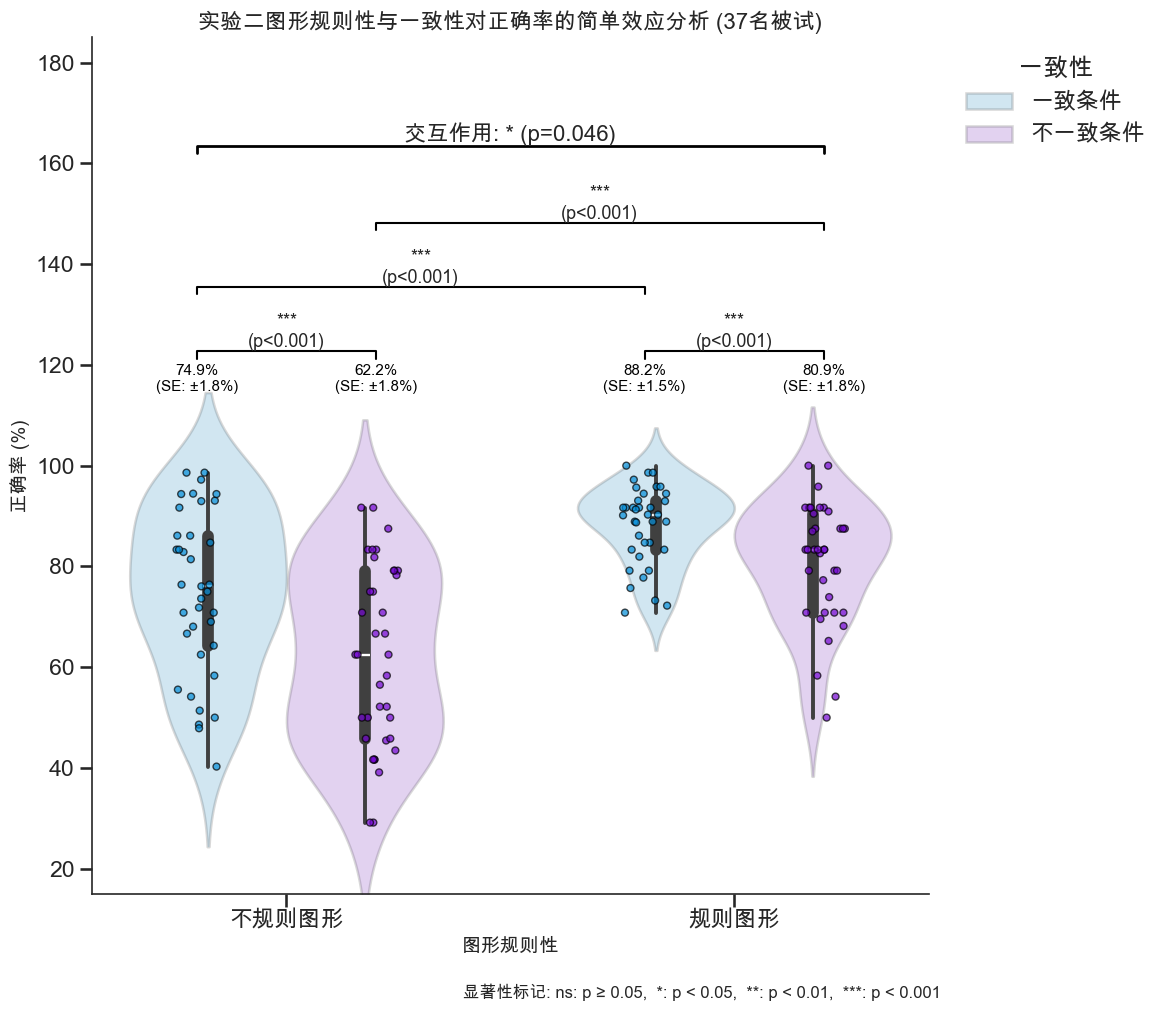



====== 报 告 专 用 数 据 (校正后) ======
[不规则图形 - 一致条件]
  均值 (Mean)  : 74.89%
  标准误 (SE)  : ±1.85%
  95%置信区间 : [71.15%, 78.63%] (半宽: ±3.74%)
---------------------------------------------
[不规则图形 - 不一致条件]
  均值 (Mean)  : 62.25%
  标准误 (SE)  : ±1.82%
  95%置信区间 : [58.57%, 65.93%] (半宽: ±3.68%)
---------------------------------------------
[规则图形 - 一致条件]
  均值 (Mean)  : 88.23%
  标准误 (SE)  : ±1.54%
  95%置信区间 : [85.11%, 91.36%] (半宽: ±3.13%)
---------------------------------------------
[规则图形 - 不一致条件]
  均值 (Mean)  : 80.88%
  标准误 (SE)  : ±1.81%
  95%置信区间 : [77.21%, 84.55%] (半宽: ±3.67%)
---------------------------------------------

分析结果与高分辨率图表已保存至: /Users/zhangqianqian/Documents/PKU/实验/实验二数据/多被试分析结果_ANOVA


In [5]:
# 多份文件的数据处理与方差分析 - 正确率分析
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from matplotlib.font_manager import FontProperties
import traceback
import scipy.stats as stats

# 设置中文字体
try:
    plt.rcParams['font.sans-serif'] = ['SimHei', 'PingFang SC', 'Microsoft YaHei', 'STHeiti', 'Heiti SC', 'Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False
    plt.rcParams['font.family'] = 'sans-serif'
    font = FontProperties(family='sans-serif', size=12)
except Exception as e:
    print(f"字体设置出错: {e}")

# 创建输出文件夹
output_folder = os.path.join(os.getcwd(), '多被试分析结果_ANOVA')
os.makedirs(output_folder, exist_ok=True)

# 数据文件路径
data_path = '/Users/zhangqianqian/Documents/PKU/实验/实验二数据/Source5'

try:
    # 读取并合并所有数据
    all_data = []
    subject_count = 0
    file_count = 0
    
    # 检查目录是否存在
    if not os.path.exists(data_path):
        raise FileNotFoundError(f"找不到目录: {data_path}")
    
    print(f"开始读取目录: {data_path}")
    
    # 列出所有文件
    all_files = sorted(os.listdir(data_path))
    excel_files = [f for f in all_files if f.lower().endswith(('.xlsx', '.xls'))]
    
    print(f"目录中找到 {len(excel_files)} 个Excel文件")
    
    # 处理每个文件
    for file_name in excel_files:
        try:
            file_count += 1
            file_path = os.path.join(data_path, file_name)
            print(f"处理文件 {file_count}/{len(excel_files)}: {file_name}")
            
            # 读取Excel文件
            df = pd.read_excel(file_path)
            print(f"  - 包含 {len(df)} 行数据")
            
            # 提取被试ID - 从文件名或文件内容
            subject_id = None
            try:
                # 尝试从文件名中提取数字作为被试ID
                import re
                subject_id_matches = re.findall(r'\d+', file_name)
                if subject_id_matches:
                    subject_id = int(subject_id_matches[0])
                # 如果文件中已有Subject列，使用它的唯一值
                elif 'Subject' in df.columns:
                    subject_id = df['Subject'].unique()[0]
            except Exception as ex:
                print(f"  - 从文件名提取被试ID时出错: {ex}")
                
            # 如果无法提取ID，使用递增的计数
            if subject_id is None:
                subject_count += 1
                subject_id = subject_count
            else:
                subject_count = max(subject_count, subject_id)
                
            print(f"  - 被试ID: {subject_id}")
            
            # 添加/更新被试ID列
            df['SubjectID'] = subject_id
            
            # 保存原始列名
            original_columns = df.columns.tolist()
            
            # 提取必要的信息 - 与您之前的代码相同
            df['shape_str'] = df['Shape'].astype(str)
            df['左侧数字'] = df['shape_str'].str[0].astype(int)
            df['右侧数字'] = df['shape_str'].str[1].astype(int)
            
            # 分析不同条件
            df['条件类型'] = '未分类'
            df['一致性'] = '未分类'
            df['被查看的数字'] = np.nan
            df['被查看的位置'] = '未分类'
            df['图形规则性'] = '未分类'
            
            # 左手一致条件 (Cue=0, Report=0)：看左侧图形
            left_consistent = (df['Cue'] == 0) & (df['Report'] == 0)
            df.loc[left_consistent, '条件类型'] = '左手一致'
            df.loc[left_consistent, '一致性'] = '一致条件'
            df.loc[left_consistent, '被查看的数字'] = df.loc[left_consistent, '左侧数字']
            df.loc[left_consistent, '被查看的位置'] = '左侧'
            df.loc[left_consistent & df['左侧数字'].isin([1, 2]), '图形规则性'] = '规则图形'
            df.loc[left_consistent & df['左侧数字'].isin([3, 4]), '图形规则性'] = '不规则图形'
            
            # 右手一致条件 (Cue=1, Report=1)：看右侧图形
            right_consistent = (df['Cue'] == 1) & (df['Report'] == 1)
            df.loc[right_consistent, '条件类型'] = '右手一致'
            df.loc[right_consistent, '一致性'] = '一致条件'
            df.loc[right_consistent, '被查看的数字'] = df.loc[right_consistent, '右侧数字']
            df.loc[right_consistent, '被查看的位置'] = '右侧'
            df.loc[right_consistent & df['右侧数字'].isin([1, 2]), '图形规则性'] = '规则图形'
            df.loc[right_consistent & df['右侧数字'].isin([3, 4]), '图形规则性'] = '不规则图形'
            
            # 左手不一致条件 (Cue=0, Report=1)：看右侧图形
            left_inconsistent = (df['Cue'] == 0) & (df['Report'] == 1)
            df.loc[left_inconsistent, '条件类型'] = '左手不一致'
            df.loc[left_inconsistent, '一致性'] = '不一致条件'
            df.loc[left_inconsistent, '被查看的数字'] = df.loc[left_inconsistent, '右侧数字']
            df.loc[left_inconsistent, '被查看的位置'] = '右侧'
            df.loc[left_inconsistent & df['右侧数字'].isin([1, 2]), '图形规则性'] = '规则图形'
            df.loc[left_inconsistent & df['右侧数字'].isin([3, 4]), '图形规则性'] = '不规则图形'
            
            # 右手不一致条件 (Cue=1, Report=0)：看左侧图形
            right_inconsistent = (df['Cue'] == 1) & (df['Report'] == 0)
            df.loc[right_inconsistent, '条件类型'] = '右手不一致'
            df.loc[right_inconsistent, '一致性'] = '不一致条件'
            df.loc[right_inconsistent, '被查看的数字'] = df.loc[right_inconsistent, '左侧数字']
            df.loc[right_inconsistent, '被查看的位置'] = '左侧'
            df.loc[right_inconsistent & df['左侧数字'].isin([1, 2]), '图形规则性'] = '规则图形'
            df.loc[right_inconsistent & df['左侧数字'].isin([3, 4]), '图形规则性'] = '不规则图形'
            
            # 确保是否正确的列存在并且格式正确
            if 'feedback' in df.columns:
                df['是否正确'] = df['feedback'].astype(int)
            else:
                print(f"  - 警告: 文件缺少feedback列，无法判断正确性")
                continue  # 跳过这个文件
            
            # 移除shape_str临时列
            if 'shape_str' in df.columns:
                df = df.drop('shape_str', axis=1)
            
            # 添加这个处理好的数据到列表
            all_data.append(df)
            
            # 可选：为每个被试单独保存处理后的数据
            # subject_folder = os.path.join(output_folder, f'被试{subject_id}')
            # os.makedirs(subject_folder, exist_ok=True)
            # df.to_excel(os.path.join(subject_folder, f'被试{subject_id}_处理后.xlsx'), index=False)
            
        except Exception as e:
            print(f"处理文件 {file_name} 时出错: {e}")
            traceback.print_exc()
    
    print(f"\n成功处理了 {len(all_data)} 个文件，共 {subject_count} 名被试的数据")

    # 合并所有被试数据
    if not all_data:
        raise ValueError("没有成功处理任何数据")
        
    df_all = pd.concat(all_data, ignore_index=True)
    print(f"合并后的数据包含 {len(df_all)} 行")
    
    # 剔除无效RT（如果有这种需求）
    if 'RT' in df_all.columns:
        print(f"剔除无效RT前的数据量：{len(df_all)}")
        df_all = df_all[df_all['RT'] != -999].copy()
        print(f"剔除无效RT后的数据量：{len(df_all)}")

    print("\n============ 基本描述统计 ============")
    print(f"最终有效被试总数 (N): {len(df_all['SubjectID'].unique())} 人")
    age_col = 'Age' if 'Age' in df_all.columns else ('age' if 'age' in df_all.columns else None)
    if age_col:
        subject_ages = df_all.groupby('SubjectID')[age_col].first().dropna()
        if not subject_ages.empty:
            print(f"被试年龄均值 (Mean): {subject_ages.mean():.2f} 岁")
            print(f"被试年龄标准差 (SD): {subject_ages.std(ddof=1):.2f}")
    else:
        print("未找到被试年龄列 (Age/age)，无法统计。")
    print("======================================\n")
    
    # 按被试和条件统计正确率
    subject_stats = df_all.groupby(['SubjectID', '图形规则性', '一致性'])['是否正确'].agg(['mean', 'count']).reset_index()
    subject_stats.columns = ['SubjectID', '图形规则性', '一致性', '正确率', '试次数']
    subject_stats['正确率%'] = subject_stats['正确率'] * 100  # 转换为百分比
    
    print("\n===== 各被试各条件正确率 =====")
    print(subject_stats.head())
    
    # 按条件计算平均正确率
    acc_stats = subject_stats.groupby(['图形规则性', '一致性'])[['正确率', '正确率%']].agg([
        ('平均值', 'mean'),
        ('标准差', 'std'),
        ('标准误', lambda x: x.std() / np.sqrt(len(x))),
        ('被试数', 'count')
    ]).reset_index()
    
    print("\n===== 各条件的平均正确率 =====")
    print(acc_stats)
    
    # 保存汇总表
    subject_stats.to_excel(os.path.join(output_folder, '各被试条件正确率.xlsx'), index=False)
    
    # 重新组织数据以便于显示
    acc_summary = pd.DataFrame({
        '条件': ['规则一致', '规则不一致', '不规则一致', '不规则不一致'],
        '平均正确率': [
            subject_stats[(subject_stats['图形规则性'] == '规则图形') & (subject_stats['一致性'] == '一致条件')]['正确率%'].mean(),
            subject_stats[(subject_stats['图形规则性'] == '规则图形') & (subject_stats['一致性'] == '不一致条件')]['正确率%'].mean(),
            subject_stats[(subject_stats['图形规则性'] == '不规则图形') & (subject_stats['一致性'] == '一致条件')]['正确率%'].mean(),
            subject_stats[(subject_stats['图形规则性'] == '不规则图形') & (subject_stats['一致性'] == '不一致条件')]['正确率%'].mean()
        ],
        '标准误': [
            subject_stats[(subject_stats['图形规则性'] == '规则图形') & (subject_stats['一致性'] == '一致条件')]['正确率%'].std() / 
            np.sqrt(len(subject_stats[(subject_stats['图形规则性'] == '规则图形') & (subject_stats['一致性'] == '一致条件')])),
            subject_stats[(subject_stats['图形规则性'] == '规则图形') & (subject_stats['一致性'] == '不一致条件')]['正确率%'].std() / 
            np.sqrt(len(subject_stats[(subject_stats['图形规则性'] == '规则图形') & (subject_stats['一致性'] == '不一致条件')])),
            subject_stats[(subject_stats['图形规则性'] == '不规则图形') & (subject_stats['一致性'] == '一致条件')]['正确率%'].std() / 
            np.sqrt(len(subject_stats[(subject_stats['图形规则性'] == '不规则图形') & (subject_stats['一致性'] == '一致条件')])),
            subject_stats[(subject_stats['图形规则性'] == '不规则图形') & (subject_stats['一致性'] == '不一致条件')]['正确率%'].std() / 
            np.sqrt(len(subject_stats[(subject_stats['图形规则性'] == '不规则图形') & (subject_stats['一致性'] == '不一致条件')]))
        ]
    })
    
    print("\n===== 条件汇总 =====")
    print(acc_summary)
    
    # ===== 进行方差分析 =====
    print("\n===== 开始进行正确率的重复测量方差分析 =====")
    
    try:
        # 检查每个被试是否在所有条件下都有数据
        condition_count = subject_stats.groupby('SubjectID').size()
        valid_subjects = condition_count[condition_count == 4].index.tolist()
        
        if len(valid_subjects) < subject_count:
            print(f"警告: 有 {subject_count - len(valid_subjects)} 名被试不具备所有条件的数据")
            print(f"只有 {len(valid_subjects)} 名被试将被用于方差分析")
        
        # 只保留有完整数据的被试
        valid_data = subject_stats[subject_stats['SubjectID'].isin(valid_subjects)]
        
        # 使用pingouin进行重复测量方差分析
        aov = pg.rm_anova(
            data=valid_data,
            dv='正确率',
            within=['图形规则性', '一致性'],
            subject='SubjectID',
            detailed=True
        )
        
        print("\n重复测量方差分析结果:")
        print(aov)
        
        # 保存ANOVA结果
        aov.to_excel(os.path.join(output_folder, '正确率方差分析结果.xlsx'), index=False)
        
        # 获取ANOVA的p值
        p_values = {}
        for _, row in aov.iterrows():
            source = row['Source']
            p = row['p-unc']
            p_values[source] = p
        
                # ===== 绘制风琴图与散点图 (引入95%置信区间) =====
        import scipy.stats as stats
        
        # 计算 95% CI (Cousineau-Morey 校正)
        k = 4 # 2x2 设计共有4个条件
        grand_mean = valid_data['正确率%'].mean()
        valid_data['acc_norm'] = valid_data['正确率%'] - valid_data.groupby('SubjectID')['正确率%'].transform('mean') + grand_mean
        morey_correction = np.sqrt(k / (k - 1))
        
        n_subj = len(valid_subjects)
        t_crit = stats.t.ppf(0.975, df=n_subj-1)
        
        summary_plot = (valid_data.groupby(['图形规则性', '一致性'])
                   .agg(mean=('正确率%','mean'),
                        se_ws=('acc_norm', lambda x: x.std(ddof=1)/np.sqrt(x.count())))
                   .reset_index())
        summary_plot['se_ws'] *= morey_correction
        summary_plot['ci_95'] = summary_plot['se_ws'] * t_crit
        
        # 开始绘图
        sns.set(style='ticks', context='talk')
        plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'PingFang SC', 'Microsoft YaHei']
        plt.rcParams['axes.unicode_minus'] = False
        
        fig, ax = plt.subplots(figsize=(12, 10))
        
        rule_order = ['不规则图形', '规则图形']
        cons_order = ['一致条件', '不一致条件']
        
        # 沿用之前的颜色：一致为青色，不一致为紫红色
        custom_colors = ["#028DD8", "#7205D1"] 
        
        # 1. 绘制风琴图（小提琴图）
        sns.violinplot(
            data=valid_data, x='图形规则性', y='正确率%', hue='一致性',
            order=rule_order, hue_order=cons_order,
            inner="box", palette=custom_colors, ax=ax, width=0.7, density_norm="width", alpha=0.2
        )
        
        # 2. 叠加被试数据散点
        sns.stripplot(
            data=valid_data, x='图形规则性', y='正确率%', hue='一致性',
            order=rule_order, hue_order=cons_order,
            dodge=True, edgecolor='black', linewidth=1, alpha=0.7, size=5, palette=custom_colors, ax=ax
        )
        
        # 3. Y轴范围动态调整
        y_max = valid_data['正确率%'].max()
        y_min = valid_data['正确率%'].min()
        yr = y_max - y_min
        ax.set_ylim(y_min - 0.2 * yr, y_max + 1.2 * yr) # 留出大量空间给顶部的图例和连线
        
        # 4. 标注均值与标准误 (SE)，图上仅显示 SE 保持清爽
        for i, rule in enumerate(rule_order):
            for j, cons in enumerate(cons_order):
                offset = -0.2 if j == 0 else 0.2
                x_pos = i + offset
                row = summary_plot.loc[(summary_plot['图形规则性']==rule) & (summary_plot['一致性']==cons)].iloc[0]
                m_val = row['mean']
                se_val = row['se_ws']
                
                # 图上文字：仅保留平均值与 SE
                ax.text(x_pos, y_max + 0.2 * yr, f'{m_val:.1f}%\n(SE: ±{se_val:.1f}%)',
                        ha='center', va='bottom', fontsize=11, color='black')
        
        # 5. 计算并画简单效应连线
        base_y = y_max + 0.3 * yr
        step = 0.12 * yr 
    
        def get_stars(p_val):
            return 'ns' if p_val >= 0.05 else ('*' if p_val >= 0.01 else ('**' if p_val >= 0.001 else '***'))
            
        def add_simple_line(x_start, x_end, y_h, p_val):
            ax.plot([x_start, x_start, x_end, x_end], [y_h, y_h + 0.02*yr, y_h + 0.02*yr, y_h], color='black', linewidth=1.5)
            stars = get_stars(p_val)
            p_str = "<0.001" if p_val < 0.001 else f"={p_val:.3f}"
            ax.text((x_start + x_end) / 2, y_h + 0.02*yr, f'{stars}\n(p{p_str})', ha='center', va='bottom', fontsize=13)
    
        # (1) 同不规则图形下：一致 vs 不一致
        d_irreg_con = valid_data[(valid_data['图形规则性'] == '不规则图形') & (valid_data['一致性'] == '一致条件')].set_index('SubjectID')['正确率%']
        d_irreg_incon = valid_data[(valid_data['图形规则性'] == '不规则图形') & (valid_data['一致性'] == '不一致条件')].set_index('SubjectID')['正确率%']
        common1 = d_irreg_con.index.intersection(d_irreg_incon.index)
        p_irreg = float(pg.ttest(d_irreg_con.loc[common1], d_irreg_incon.loc[common1], paired=True)['p-val'].iloc[0])
        add_simple_line(0 - 0.2, 0 + 0.2, base_y, p_irreg)
    
        # (2) 同规则图形下：一致 vs 不一致
        d_reg_con = valid_data[(valid_data['图形规则性'] == '规则图形') & (valid_data['一致性'] == '一致条件')].set_index('SubjectID')['正确率%']
        d_reg_incon = valid_data[(valid_data['图形规则性'] == '规则图形') & (valid_data['一致性'] == '不一致条件')].set_index('SubjectID')['正确率%']
        common2 = d_reg_con.index.intersection(d_reg_incon.index)
        p_reg = float(pg.ttest(d_reg_con.loc[common2], d_reg_incon.loc[common2], paired=True)['p-val'].iloc[0])
        add_simple_line(1 - 0.2, 1 + 0.2, base_y, p_reg)
    
        # (3) 跨条件：一致条件内的不规则 vs 规则
        y_across1 = base_y + step * 1.5
        d_con_irreg = valid_data[(valid_data['图形规则性'] == '不规则图形') & (valid_data['一致性'] == '一致条件')].set_index('SubjectID')['正确率%']
        d_con_reg = valid_data[(valid_data['图形规则性'] == '规则图形') & (valid_data['一致性'] == '一致条件')].set_index('SubjectID')['正确率%']
        common3 = d_con_irreg.index.intersection(d_con_reg.index)
        p_con = float(pg.ttest(d_con_irreg.loc[common3], d_con_reg.loc[common3], paired=True)['p-val'].iloc[0])
        add_simple_line(-0.2, 0.8, y_across1, p_con)  
    
        # (4) 跨条件：不一致条件内的不规则 vs 规则
        y_across2 = y_across1 + step * 1.5
        d_incon_irreg = valid_data[(valid_data['图形规则性'] == '不规则图形') & (valid_data['一致性'] == '不一致条件')].set_index('SubjectID')['正确率%']
        d_incon_reg = valid_data[(valid_data['图形规则性'] == '规则图形') & (valid_data['一致性'] == '不一致条件')].set_index('SubjectID')['正确率%']
        common4 = d_incon_irreg.index.intersection(d_incon_reg.index)
        p_incon = float(pg.ttest(d_incon_irreg.loc[common4], d_incon_reg.loc[common4], paired=True)['p-val'].iloc[0])
        add_simple_line(0.2, 1.2, y_across2, p_incon)
    
        # (5) 总体交互作用线
        p_int = p_values.get('图形规则性 * 一致性', float('nan'))
        star_int = get_stars(p_int)
        y_inter = y_across2 + step * 1.8
        ax.plot([-0.2, -0.2, 1.2, 1.2], [y_inter, y_inter + 0.02*yr, y_inter + 0.02*yr, y_inter], color='black', linewidth=2.0)
        p_str_int = "<0.001" if p_int < 0.001 else f"={p_int:.3f}"
        ax.text(0.5, y_inter + 0.02*yr, f'交互作用: {star_int} (p{p_str_int})', 
                ha='center', va='bottom', fontsize=16, fontweight='bold')
    
        # ---- 去除右侧与上侧边框 ----
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        for side in ['left','bottom']:
            ax.spines[side].set_linewidth(1.2)
    
        ax.set_ylabel('正确率 (%)', fontsize=14)
        ax.set_xlabel('图形规则性', fontsize=14)
        ax.set_title(f'实验二图形规则性与一致性对正确率的简单效应分析 ({n_subj}名被试)', fontsize=16)
    
        # 去除seaborn图例的重复映射
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles=handles[:len(cons_order)], labels=cons_order, title='一致性', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
        
        # 去除seaborn图例的重复映射
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles=handles[:len(cons_order)], labels=cons_order, title='一致性', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
        
        # ======== 新加回来的显著性注解 ======== 
        result_text = "显著性标记: ns: p ≥ 0.05,  *: p < 0.05,  **: p < 0.01,  ***: p < 0.001"
        plt.figtext(0.40, -0.015, result_text, fontsize=12)
        # ==================================

        plt.tight_layout()
        
        # 导出图片
        plt.savefig(os.path.join(output_folder, '正确率_风琴图_95CI.png'), dpi=300, bbox_inches='tight')
        plt.savefig(os.path.join(output_folder, '正确率_风琴图_95CI.pdf'), bbox_inches='tight')
        plt.show()
        
        # 储存全量数据表格文件
        df_all.to_excel(os.path.join(output_folder, '合并后的完整数据.xlsx'), index=False)
        
        # ====== 新增：在输出区打印出置信区间，供写论文使用 ======
        print("\n\n" + "="*45)
        print("====== 报 告 专 用 数 据 (校正后) ======")
        print("="*45)
        for idx, row in summary_plot.iterrows():
            rule = row['图形规则性']
            cons = row['一致性']
            m_val = row['mean']
            se_val = row['se_ws']
            ci_val = row['ci_95']
            print(f"[{rule} - {cons}]")
            print(f"  均值 (Mean)  : {m_val:.2f}%")
            print(f"  标准误 (SE)  : ±{se_val:.2f}%")
            print(f"  95%置信区间 : [{m_val - ci_val:.2f}%, {m_val + ci_val:.2f}%] (半宽: ±{ci_val:.2f}%)")
            print("-" * 45)

        print(f"\n分析结果与高分辨率图表已保存至: {output_folder}")
        
    except Exception as e:
        print(f"方差分析与绘图过程中出错: {e}")
        traceback.print_exc()

except Exception as e:
    print(f"数据处理过程中出错: {e}")
    traceback.print_exc()

# 反应时方差分析

开始读取目录: /Users/zhangqianqian/Documents/PKU/实验/实验二数据/Source5
目录中找到 37 个Excel文件


/opt/miniconda3/lib/python3.12/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/opt/miniconda3/lib/python3.12/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)



重复测量方差分析结果:
        Source            SS  ddof1  ddof2            MS          F  \
0        图形规则性  2.926892e+05      1     36  2.926892e+05  13.851798   
1          一致性  2.269991e+06      1     36  2.269991e+06  66.312334   
2  图形规则性 * 一致性  1.058452e+03      1     36  1.058452e+03   0.086624   

          p-unc     p-GG-corr       ng2  eps  
0  6.731094e-04  6.731094e-04  0.040253  1.0  
1  1.105791e-09  1.105791e-09  0.245441  1.0  
2  7.702037e-01  7.702037e-01  0.000152  1.0  


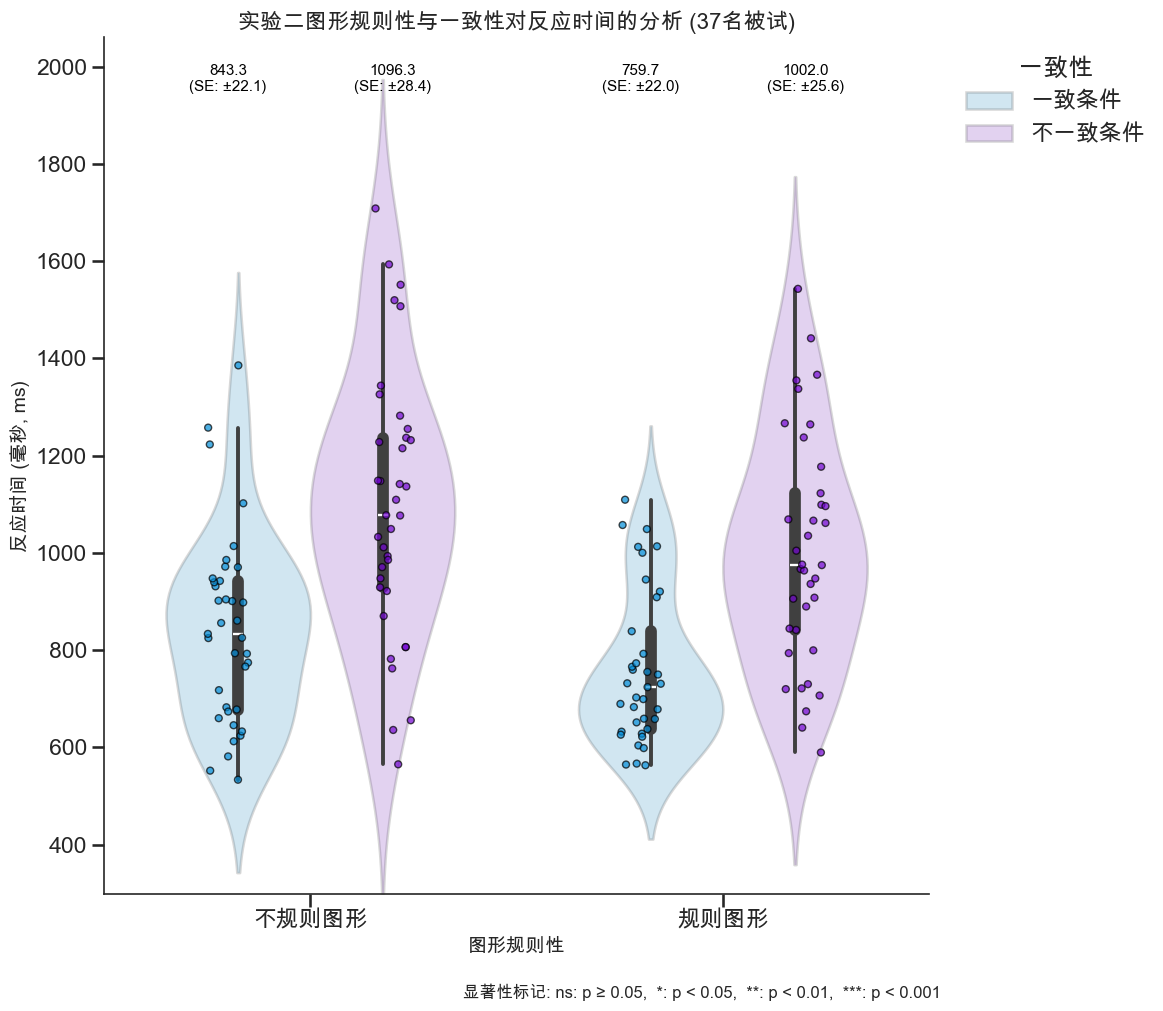



====== 主效应统计与正文文字生成 ======
【主效应描述性统计 (校正后 95% CI)】
一致条件: 801.5 ms, 95% CI [757.9, 845.1]
不一致条件: 1049.2 ms, 95% CI [1005.6, 1092.8]
规则图形: 880.9 ms, 95% CI [846.6, 915.1]
不规则图形: 969.8 ms, 95% CI [935.5, 1004.1]

【你可以直接复制以下这段话放入论文中】
如图 3.15 所示，对受试者反应时的 2 × 2 重复测量方差分析结果显示，图形的语义规则性与注意一致性之间不存在显著的交互作用（F(1, 36) = 0.09, p = .770, ηp² = 0.000）。由于交互作用不显著，分析重点转向两大主效应。
结果表明，注意一致性的主效应显著（F(1, 36) = 66.31, p < .001, ηp² = 0.245）：无论图形是否具有语义规则性，受试者在注意一致条件下的反应时（M = 801.5 ms, 95% CI [757.9, 845.1]）均显著快于注意不一致条件（M = 1049.2 ms, 95% CI [1005.6, 1092.8]）。
同时，语义规则性的主效应亦显著（F(1, 36) = 13.85, p < .001, ηp² = 0.040）：无论空间注意是否一致，受试者对语义规则图形的认知加工速度（M = 880.9 ms, 95% CI [846.6, 915.1]）均显著快于非语义不规则图形（M = 969.8 ms, 95% CI [935.5, 1004.1]）。
上述结果表明，内源性空间注意与语义先验对反应时的促进作用是相互独立的。空间注意转移（即不一致条件）所引发的反应时延长代价，在规则与不规则图形中是平行且等量的（未产生显著交互）。这提示我们在行为学的反应速度层面上，语义先验未能表现出对注意冲突的特异性缓冲作用，两者的机制表现为单纯的线性叠加。


In [2]:
# 多份文件的数据处理与方差分析 - 反应时分析(RT)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from matplotlib.font_manager import FontProperties
import traceback

# 设置中文字体
try:
    plt.rcParams['font.sans-serif'] = ['SimHei', 'PingFang SC', 'Microsoft YaHei', 'STHeiti', 'Heiti SC', 'Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False
    plt.rcParams['font.family'] = 'sans-serif'
    font = FontProperties(family='sans-serif', size=12)
except Exception as e:
    print(f"字体设置出错: {e}")

# 创建输出文件夹
output_folder = os.path.join(os.getcwd(), '多被试分析结果_ANOVA_RT')
os.makedirs(output_folder, exist_ok=True)

# 数据文件路径
data_path = '/Users/zhangqianqian/Documents/PKU/实验/实验二数据/Source5'

try:
    # 读取并合并所有数据
    all_data = []
    subject_count = 0
    file_count = 0
    
    # 检查目录是否存在
    if not os.path.exists(data_path):
        raise FileNotFoundError(f"找不到目录: {data_path}")
    
    print(f"开始读取目录: {data_path}")
    
    # 列出所有文件
    all_files = sorted(os.listdir(data_path))
    excel_files = [f for f in all_files if f.lower().endswith(('.xlsx', '.xls'))]
    
    print(f"目录中找到 {len(excel_files)} 个Excel文件")
    
    # 处理每个文件
    for file_name in excel_files:
        try:
            file_count += 1
            file_path = os.path.join(data_path, file_name)
            
            # 读取Excel文件
            df = pd.read_excel(file_path)
            
            # 提取被试ID
            subject_id = None
            try:
                import re
                subject_id_matches = re.findall(r'\d+', file_name)
                if subject_id_matches:
                    subject_id = int(subject_id_matches[0])
                elif 'Subject' in df.columns:
                    subject_id = df['Subject'].unique()[0]
            except Exception as ex:
                pass
                
            if subject_id is None:
                subject_count += 1
                subject_id = subject_count
            else:
                subject_count = max(subject_count, subject_id)
                
            df['SubjectID'] = subject_id
            df['shape_str'] = df['Shape'].astype(str)
            df['左侧数字'] = df['shape_str'].str[0].astype(int)
            df['右侧数字'] = df['shape_str'].str[1].astype(int)
            
            # 分析不同条件
            df['条件类型'] = '未分类'
            df['一致性'] = '未分类'
            df['被查看的数字'] = np.nan
            df['被查看的位置'] = '未分类'
            df['图形规则性'] = '未分类'
            
            left_consistent = (df['Cue'] == 0) & (df['Report'] == 0)
            df.loc[left_consistent, '条件类型'] = '左手一致'
            df.loc[left_consistent, '一致性'] = '一致条件'
            df.loc[left_consistent, '被查看的数字'] = df.loc[left_consistent, '左侧数字']
            df.loc[left_consistent, '被查看的位置'] = '左侧'
            df.loc[left_consistent & df['左侧数字'].isin([1, 2]), '图形规则性'] = '规则图形'
            df.loc[left_consistent & df['左侧数字'].isin([3, 4]), '图形规则性'] = '不规则图形'
            
            right_consistent = (df['Cue'] == 1) & (df['Report'] == 1)
            df.loc[right_consistent, '条件类型'] = '右手一致'
            df.loc[right_consistent, '一致性'] = '一致条件'
            df.loc[right_consistent, '被查看的数字'] = df.loc[right_consistent, '右侧数字']
            df.loc[right_consistent, '被查看的位置'] = '右侧'
            df.loc[right_consistent & df['右侧数字'].isin([1, 2]), '图形规则性'] = '规则图形'
            df.loc[right_consistent & df['右侧数字'].isin([3, 4]), '图形规则性'] = '不规则图形'
            
            left_inconsistent = (df['Cue'] == 0) & (df['Report'] == 1)
            df.loc[left_inconsistent, '条件类型'] = '左手不一致'
            df.loc[left_inconsistent, '一致性'] = '不一致条件'
            df.loc[left_inconsistent, '被查看的数字'] = df.loc[left_inconsistent, '右侧数字']
            df.loc[left_inconsistent, '被查看的位置'] = '右侧'
            df.loc[left_inconsistent & df['右侧数字'].isin([1, 2]), '图形规则性'] = '规则图形'
            df.loc[left_inconsistent & df['右侧数字'].isin([3, 4]), '图形规则性'] = '不规则图形'
            
            right_inconsistent = (df['Cue'] == 1) & (df['Report'] == 0)
            df.loc[right_inconsistent, '条件类型'] = '右手不一致'
            df.loc[right_inconsistent, '一致性'] = '不一致条件'
            df.loc[right_inconsistent, '被查看的数字'] = df.loc[right_inconsistent, '左侧数字']
            df.loc[right_inconsistent, '被查看的位置'] = '左侧'
            df.loc[right_inconsistent & df['左侧数字'].isin([1, 2]), '图形规则性'] = '规则图形'
            df.loc[right_inconsistent & df['左侧数字'].isin([3, 4]), '图形规则性'] = '不规则图形'
            
            if 'feedback' in df.columns:
                df['是否正确'] = df['feedback'].astype(int)
            else:
                df['是否正确'] = 1
            
            if 'shape_str' in df.columns:
                df = df.drop('shape_str', axis=1)
            
            all_data.append(df)
            
        except Exception as e:
            traceback.print_exc()

    df_all = pd.concat(all_data, ignore_index=True)
    df_all = df_all[df_all['RT'] != -999].copy()  
    df_all = df_all[df_all['是否正确'] == 1].copy()  
    df_all['RT_ms'] = df_all['RT'] * 1000  
    
    outliers = (df_all['RT_ms'] < 200) | (df_all['RT_ms'] > 2000)
    if outliers.any():
        df_all = df_all[~outliers].copy()
    
    subject_stats = df_all.groupby(['SubjectID', '图形规则性', '一致性'])['RT_ms'].agg([
        ('平均RT', 'mean'),
        ('RT中位数', 'median'),
        ('RT标准差', 'std'),
        ('试次数', 'count')
    ]).reset_index()
    
    rt_stats = subject_stats.groupby(['图形规则性', '一致性'])[['平均RT', 'RT中位数']].agg([
        ('平均值', 'mean'),
        ('标准差', 'std'),
        ('标准误', lambda x: x.std() / np.sqrt(len(x))),
        ('被试数', 'count')
    ]).reset_index()
    
    subject_stats.to_excel(os.path.join(output_folder, '各被试条件反应时间.xlsx'), index=False)
    
    rt_summary = pd.DataFrame({
        '条件': ['规则一致', '规则不一致', '不规则一致', '不规则不一致'],
        '平均RT (ms)': [
            subject_stats[(subject_stats['图形规则性'] == '规则图形') & (subject_stats['一致性'] == '一致条件')]['平均RT'].mean(),
            subject_stats[(subject_stats['图形规则性'] == '规则图形') & (subject_stats['一致性'] == '不一致条件')]['平均RT'].mean(),
            subject_stats[(subject_stats['图形规则性'] == '不规则图形') & (subject_stats['一致性'] == '一致条件')]['平均RT'].mean(),
            subject_stats[(subject_stats['图形规则性'] == '不规则图形') & (subject_stats['一致性'] == '不一致条件')]['平均RT'].mean()
        ],
        '标准误': [
            subject_stats[(subject_stats['图形规则性'] == '规则图形') & (subject_stats['一致性'] == '一致条件')]['平均RT'].std() / 
            np.sqrt(len(subject_stats[(subject_stats['图形规则性'] == '规则图形') & (subject_stats['一致性'] == '一致条件')])),
            subject_stats[(subject_stats['图形规则性'] == '规则图形') & (subject_stats['一致性'] == '不一致条件')]['平均RT'].std() / 
            np.sqrt(len(subject_stats[(subject_stats['图形规则性'] == '规则图形') & (subject_stats['一致性'] == '不一致条件')])),
            subject_stats[(subject_stats['图形规则性'] == '不规则图形') & (subject_stats['一致性'] == '一致条件')]['平均RT'].std() / 
            np.sqrt(len(subject_stats[(subject_stats['图形规则性'] == '不规则图形') & (subject_stats['一致性'] == '一致条件')])),
            subject_stats[(subject_stats['图形规则性'] == '不规则图形') & (subject_stats['一致性'] == '不一致条件')]['平均RT'].std() / 
            np.sqrt(len(subject_stats[(subject_stats['图形规则性'] == '不规则图形') & (subject_stats['一致性'] == '不一致条件')]))
        ]
    })
    
    # ===== 进行方差分析 =====
    try:
        condition_count = subject_stats.groupby('SubjectID').size()
        valid_subjects = condition_count[condition_count == 4].index.tolist()
        valid_data = subject_stats[subject_stats['SubjectID'].isin(valid_subjects)]
        
        aov = pg.rm_anova(
            data=valid_data,
            dv='平均RT',
            within=['图形规则性', '一致性'],
            subject='SubjectID',
            detailed=True
        )
        
        print("\n重复测量方差分析结果:")
        print(aov)
        aov.to_excel(os.path.join(output_folder, '反应时方差分析结果.xlsx'), index=False)
        
        p_values = {}
        for _, row in aov.iterrows():
            source = row['Source']
            p = row['p-unc']
            p_values[source] = p
        
        # ===== 绘制风琴图与散点图 (引入95%置信区间) =====
        import scipy.stats as stats
        
        # 计算 95% CI (Cousineau-Morey 校正)
        k = 4 # 2x2 设计共有4个条件
        grand_mean = valid_data['平均RT'].mean()
        valid_data['rt_norm'] = valid_data['平均RT'] - valid_data.groupby('SubjectID')['平均RT'].transform('mean') + grand_mean
        morey_correction = np.sqrt(k / (k - 1))
        
        n_subj = len(valid_subjects)
        t_crit = stats.t.ppf(0.975, df=n_subj-1)
        
        summary_plot = (valid_data.groupby(['图形规则性', '一致性'])
                   .agg(mean=('平均RT','mean'),
                        se_ws=('rt_norm', lambda x: x.std(ddof=1)/np.sqrt(x.count())))
                   .reset_index())
        summary_plot['se_ws'] *= morey_correction
        summary_plot['ci_95'] = summary_plot['se_ws'] * t_crit
        
        # 开始绘图
        sns.set_theme(style='ticks', context='talk')
        plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'PingFang SC', 'Microsoft YaHei']
        plt.rcParams['axes.unicode_minus'] = False
        
        fig, ax = plt.subplots(figsize=(12, 10))
        
        rule_order = ['不规则图形', '规则图形']
        cons_order = ['一致条件', '不一致条件']
        
        # 沿用之前的颜色：一致为青色，不一致为紫红色
        custom_colors = ["#028DD8", "#7205D1"] 
        
        # 1. 绘制风琴图（小提琴图）
        sns.violinplot(
            data=valid_data, x='图形规则性', y='平均RT', hue='一致性',
            order=rule_order, hue_order=cons_order,
            inner="box", palette=custom_colors, ax=ax, width=0.7, density_norm="width", alpha=0.2
        )
        
        # 2. 叠加被试数据散点
        sns.stripplot(
            data=valid_data, x='图形规则性', y='平均RT', hue='一致性',
            order=rule_order, hue_order=cons_order,
            dodge=True, edgecolor='black', linewidth=1, alpha=0.7, size=5, palette=custom_colors, ax=ax
        )
        
        # 3. Y轴范围动态调整 (因为不用画连线，所以不用留那么多顶部空间了)
        y_max = valid_data['平均RT'].max()
        y_min = valid_data['平均RT'].min()
        yr = y_max - y_min
        ax.set_ylim(y_min - 0.2 * yr, y_max + 0.3 * yr) 
        
        # 4. 标注均值与标准误 (SE)，图上仅显示 SE 保持清爽
        for i, rule in enumerate(rule_order):
            for j, cons in enumerate(cons_order):
                offset = -0.2 if j == 0 else 0.2
                x_pos = i + offset
                row = summary_plot.loc[(summary_plot['图形规则性']==rule) & (summary_plot['一致性']==cons)].iloc[0]
                m_val = row['mean']
                se_val = row['se_ws']
                
                # 图上文字：仅保留平均值与 SE (不用%)
                ax.text(x_pos, y_max + 0.2 * yr, f'{m_val:.1f}\n(SE: ±{se_val:.1f})',
                        ha='center', va='bottom', fontsize=11, color='black')
        
        # 5. 计算并画简单效应连线
        # base_y = y_max + 0.3 * yr
        # step = 0.12 * yr 
    
        # def get_stars(p_val):
            # return 'ns' if p_val >= 0.05 else ('*' if p_val >= 0.01 else ('**' if p_val >= 0.001 else '***'))
            
        # def add_simple_line(x_start, x_end, y_h, p_val):
            # ax.plot([x_start, x_start, x_end, x_end], [y_h, y_h + 0.02*yr, y_h + 0.02*yr, y_h], color='black', linewidth=1.5)
            # stars = get_stars(p_val)
            # p_str = "<0.001" if p_val < 0.001 else f"={p_val:.3f}"
            # ax.text((x_start + x_end) / 2, y_h + 0.02*yr, f'{stars}\n(p{p_str})', ha='center', va='bottom', fontsize=13)
    
        # (1) 同不规则图形下：一致 vs 不一致
        # d_irreg_con = valid_data[(valid_data['图形规则性'] == '不规则图形') & (valid_data['一致性'] == '一致条件')].set_index('SubjectID')['平均RT']
        # d_irreg_incon = valid_data[(valid_data['图形规则性'] == '不规则图形') & (valid_data['一致性'] == '不一致条件')].set_index('SubjectID')['平均RT']
        # common1 = d_irreg_con.index.intersection(d_irreg_incon.index)
        # p_irreg = float(pg.ttest(d_irreg_con.loc[common1], d_irreg_incon.loc[common1], paired=True)['p-val'].iloc[0])
        # add_simple_line(0 - 0.2, 0 + 0.2, base_y, p_irreg)
    
        # (2) 同规则图形下：一致 vs 不一致
        # d_reg_con = valid_data[(valid_data['图形规则性'] == '规则图形') & (valid_data['一致性'] == '一致条件')].set_index('SubjectID')['平均RT']
        # d_reg_incon = valid_data[(valid_data['图形规则性'] == '规则图形') & (valid_data['一致性'] == '不一致条件')].set_index('SubjectID')['平均RT']
        # common2 = d_reg_con.index.intersection(d_reg_incon.index)
        # p_reg = float(pg.ttest(d_reg_con.loc[common2], d_reg_incon.loc[common2], paired=True)['p-val'].iloc[0])
        # add_simple_line(1 - 0.2, 1 + 0.2, base_y, p_reg)
    
        # (3) 跨条件：一致条件内的不规则 vs 规则
        # y_across1 = base_y + step * 1.5
        # d_con_irreg = valid_data[(valid_data['图形规则性'] == '不规则图形') & (valid_data['一致性'] == '一致条件')].set_index('SubjectID')['平均RT']
        # d_con_reg = valid_data[(valid_data['图形规则性'] == '规则图形') & (valid_data['一致性'] == '一致条件')].set_index('SubjectID')['平均RT']
        # common3 = d_con_irreg.index.intersection(d_con_reg.index)
        # p_con = float(pg.ttest(d_con_irreg.loc[common3], d_con_reg.loc[common3], paired=True)['p-val'].iloc[0])
        # add_simple_line(-0.2, 0.8, y_across1, p_con)  
    
        # (4) 跨条件：不一致条件内的不规则 vs 规则
        # y_across2 = y_across1 + step * 1.5
        # d_incon_irreg = valid_data[(valid_data['图形规则性'] == '不规则图形') & (valid_data['一致性'] == '不一致条件')].set_index('SubjectID')['平均RT']
        # d_incon_reg = valid_data[(valid_data['图形规则性'] == '规则图形') & (valid_data['一致性'] == '不一致条件')].set_index('SubjectID')['平均RT']
        # common4 = d_incon_irreg.index.intersection(d_incon_reg.index)
        # p_incon = float(pg.ttest(d_incon_irreg.loc[common4], d_incon_reg.loc[common4], paired=True)['p-val'].iloc[0])
        # add_simple_line(0.2, 1.2, y_across2, p_incon)
    
        # (5) 总体交互作用线
        # p_int = p_values.get('图形规则性 * 一致性', float('nan'))
        # star_int = get_stars(p_int)
        # y_inter = y_across2 + step * 1.8
        # ax.plot([-0.2, -0.2, 1.2, 1.2], [y_inter, y_inter + 0.02*yr, y_inter + 0.02*yr, y_inter], color='black', linewidth=2.0)
        # p_str_int = "<0.001" if p_int < 0.001 else f"={p_int:.3f}"
        # ax.text(0.5, y_inter + 0.02*yr, f'交互作用: {star_int} (p{p_str_int})', 
                # ha='center', va='bottom', fontsize=16, fontweight='bold')
    
        # ---- 去除右侧与上侧边框 ----
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        for side in ['left','bottom']:
            ax.spines[side].set_linewidth(1.2)
    
        ax.set_ylabel('反应时间 (毫秒, ms)', fontsize=14)
        ax.set_xlabel('图形规则性', fontsize=14)
        ax.set_title(f'实验二图形规则性与一致性对反应时间的分析 ({n_subj}名被试)', fontsize=16)
    
        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > len(cons_order):
            ax.legend(handles=handles[:len(cons_order)], labels=cons_order, title='一致性', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
        else:
            ax.legend(title='一致性', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
        
        result_text = "显著性标记: ns: p ≥ 0.05,  *: p < 0.05,  **: p < 0.01,  ***: p < 0.001"
        plt.figtext(0.40, -0.015, result_text, fontsize=12)

        plt.tight_layout()
        plt.savefig(os.path.join(output_folder, '反应时_风琴图_95CI.png'), dpi=300, bbox_inches='tight')
        plt.savefig(os.path.join(output_folder, '反应时_风琴图_95CI.pdf'), bbox_inches='tight')
        plt.show()
        
        rt_stats.to_excel(os.path.join(output_folder, 'RT条件统计.xlsx'), index=True)
        rt_summary.to_excel(os.path.join(output_folder, 'RT条件汇总.xlsx'), index=True)

                # ====== 新增计算：主效应的置信区间与自动化文字生成 ======
        print("\n\n" + "="*45)
        print("====== 主效应统计与正文文字生成 ======")
        print("="*45)
        
        # 兼容不同版本的 pingouin，自动识别效应量列名 (ng2 或 np2)
        eff_col = 'np2' if 'np2' in aov.columns else 'ng2'
        
        # 获取重复测量方差分析的统计量
        f_rule = aov.loc[aov['Source'] == '图形规则性', 'F'].values[0]
        p_rule = aov.loc[aov['Source'] == '图形规则性', 'p-unc'].values[0]
        np2_rule = aov.loc[aov['Source'] == '图形规则性', eff_col].values[0]
        
        f_cons = aov.loc[aov['Source'] == '一致性', 'F'].values[0]
        p_cons = aov.loc[aov['Source'] == '一致性', 'p-unc'].values[0]
        np2_cons = aov.loc[aov['Source'] == '一致性', eff_col].values[0]
        
        f_int = aov.loc[aov['Source'] == '图形规则性 * 一致性', 'F'].values[0]
        p_int = aov.loc[aov['Source'] == '图形规则性 * 一致性', 'p-unc'].values[0]
        np2_int = aov.loc[aov['Source'] == '图形规则性 * 一致性', eff_col].values[0]
        
        # 自由度
        ddof1 = int(aov.loc[aov['Source'] == '图形规则性', 'ddof1'].values[0])
        ddof2 = int(aov.loc[aov['Source'] == '图形规则性', 'ddof2'].values[0])
        
        # 计算主效应：一致性 (Consistent vs Inconsistent)
        df_cons_main = valid_data.groupby(['SubjectID', '一致性'])['平均RT'].mean().reset_index()
        k_main = 2 # 主效应只有两个水平
        morey_corr_main = np.sqrt(k_main / (k_main - 1))
        t_crit_main = stats.t.ppf(0.975, df=n_subj-1)
        
        grand_mean_main1 = df_cons_main['平均RT'].mean()
        df_cons_main['norm'] = df_cons_main['平均RT'] - df_cons_main.groupby('SubjectID')['平均RT'].transform('mean') + grand_mean_main1
        sum_cons = df_cons_main.groupby('一致性').agg(mean=('平均RT','mean'), se=('norm', lambda x: x.std(ddof=1)/np.sqrt(x.count())))
        sum_cons['se'] *= morey_corr_main
        sum_cons['ci_95'] = sum_cons['se'] * t_crit_main
        
        con_m, con_ci = sum_cons.loc['一致条件', 'mean'], sum_cons.loc['一致条件', 'ci_95']
        incon_m, incon_ci = sum_cons.loc['不一致条件', 'mean'], sum_cons.loc['不一致条件', 'ci_95']

        # 计算主效应：图形规则性 (Regular vs Irregular)
        df_rule_main = valid_data.groupby(['SubjectID', '图形规则性'])['平均RT'].mean().reset_index()
        grand_mean_main2 = df_rule_main['平均RT'].mean()
        df_rule_main['norm'] = df_rule_main['平均RT'] - df_rule_main.groupby('SubjectID')['平均RT'].transform('mean') + grand_mean_main2
        sum_rule = df_rule_main.groupby('图形规则性').agg(mean=('平均RT','mean'), se=('norm', lambda x: x.std(ddof=1)/np.sqrt(x.count())))
        sum_rule['se'] *= morey_corr_main
        sum_rule['ci_95'] = sum_rule['se'] * t_crit_main

        reg_m, reg_ci = sum_rule.loc['规则图形', 'mean'], sum_rule.loc['规则图形', 'ci_95']
        irreg_m, irreg_ci = sum_rule.loc['不规则图形', 'mean'], sum_rule.loc['不规则图形', 'ci_95']
        
        def format_p(p):
            return "< .001" if p < 0.001 else f"= {p:.3f}".replace("= 0.", "= .")
            
        print("【主效应描述性统计 (校正后 95% CI)】")
        print(f"一致条件: {con_m:.1f} ms, 95% CI [{con_m-con_ci:.1f}, {con_m+con_ci:.1f}]")
        print(f"不一致条件: {incon_m:.1f} ms, 95% CI [{incon_m-incon_ci:.1f}, {incon_m+incon_ci:.1f}]")
        print(f"规则图形: {reg_m:.1f} ms, 95% CI [{reg_m-reg_ci:.1f}, {reg_m+reg_ci:.1f}]")
        print(f"不规则图形: {irreg_m:.1f} ms, 95% CI [{irreg_m-irreg_ci:.1f}, {irreg_m+irreg_ci:.1f}]")
        
        print("\n【你可以直接复制以下这段话放入论文中】")
        print(f"如图 3.15 所示，对受试者反应时的 2 × 2 重复测量方差分析结果显示，图形的语义规则性与注意一致性之间不存在显著的交互作用（F({ddof1}, {ddof2}) = {f_int:.2f}, p {format_p(p_int)}, ηp² = {np2_int:.3f}）。由于交互作用不显著，分析重点转向两大主效应。")
        print(f"结果表明，注意一致性的主效应显著（F({ddof1}, {ddof2}) = {f_cons:.2f}, p {format_p(p_cons)}, ηp² = {np2_cons:.3f}）：无论图形是否具有语义规则性，受试者在注意一致条件下的反应时（M = {con_m:.1f} ms, 95% CI [{con_m-con_ci:.1f}, {con_m+con_ci:.1f}]）均显著快于注意不一致条件（M = {incon_m:.1f} ms, 95% CI [{incon_m-incon_ci:.1f}, {incon_m+incon_ci:.1f}]）。")
        print(f"同时，语义规则性的主效应亦显著（F({ddof1}, {ddof2}) = {f_rule:.2f}, p {format_p(p_rule)}, ηp² = {np2_rule:.3f}）：无论空间注意是否一致，受试者对语义规则图形的认知加工速度（M = {reg_m:.1f} ms, 95% CI [{reg_m-reg_ci:.1f}, {reg_m+reg_ci:.1f}]）均显著快于非语义不规则图形（M = {irreg_m:.1f} ms, 95% CI [{irreg_m-irreg_ci:.1f}, {irreg_m+irreg_ci:.1f}]）。")
        print("上述结果表明，内源性空间注意与语义先验对反应时的促进作用是相互独立的。空间注意转移（即不一致条件）所引发的反应时延长代价，在规则与不规则图形中是平行且等量的（未产生显著交互）。这提示我们在行为学的反应速度层面上，语义先验未能表现出对注意冲突的特异性缓冲作用，两者的机制表现为单纯的线性叠加。")
    except Exception as e:
        print(f"方差分析过程中出错: {e}")
        traceback.print_exc()

except Exception as e:
    print(f"数据处理过程中出错: {e}")
    traceback.print_exc()